In [1]:
from obspy.clients.fdsn import Client
client = Client("SCEDC")
inv = client.get_stations(network="CI", station="PASC", level="response")
inv.write("CI.PASC.xml", format="STATIONXML")

In [3]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from Pipe.pipeline import preprocessar_waveform, criar_janelas

In [6]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

# Criar cliente SCEDC
client = Client("SCEDC")

# Definir o período dos seus dados (todo o dia 2016-01-01)
start = UTCDateTime("2016-01-01T00:00:00")
end = UTCDateTime("2016-01-02T00:00:00")  # um dia depois

# Baixar o inventário da estação PASC
inv = client.get_stations(
    network="CI",
    station="PASC",
    starttime=start,
    endtime=end,
    level="response"  # importante: "response" inclui a resposta instrumental
)

# Salvar em arquivo
inv.write(r"C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\scedc-pds\FDSNstationXML\C2-2CI.PASC.xml", format="STATIONXML")
print("StationXML baixado com sucesso!")

StationXML baixado com sucesso!


In [8]:
# Caminhos (ajuste se necessário)
caminho_continuo = r"C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\CI.PASC.BHZ.2016-01-01.mseed"
caminho_inv_pasc = r"C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\scedc-pds\FDSNstationXML\C2-2\C2-2CI.PASC.xml"  # ou o caminho correto

# Processar (pode levar alguns minutos, pois o arquivo tem 24h de dados)
dados_continuos, meta_continuos = preprocessar_waveform(
    caminho_continuo, caminho_inv_pasc,
    canal_alvo='BHZ', output='VEL',
    pre_filt=(0.5, 1.0, 18.0, 20.0),
    normalizar=True, plot=False  # plot=False para não travar
)

print("Processamento concluído!")
print(f"Forma dos dados: {dados_continuos.shape}")  # deve ser (n_amostras,)
print(f"Taxa de amostragem: {meta_continuos['sampling_rate']} Hz")

Processamento concluído!
Forma dos dados: (24192000,)
Taxa de amostragem: 40.0 Hz


Gerando janelas de treino 
Estimativa do número de janelas:

Amostras por janela: 30 s × 40 Hz = 1200 amostras

Passo = 1200 × (1 – 0,5) = 600 amostras

Número de janelas ≈ (24.192.000 – 1200) / 600 ≈ 40.318 janelas.

Ou seja, você terá cerca de 40 mil janelas de ruído para treinar seu autoencoder. Muito bom!

In [9]:
# Parâmetros
sr = 40.0
tamanho_seg = 30
sobreposicao = 0.5

# Gerar janelas
janelas_treino = criar_janelas(dados_continuos, sr, tamanho_seg, sobreposicao)
print(f"Janelas de treino geradas: {janelas_treino.shape}")

Janelas de treino geradas: (40319, 1200)


In [11]:
import matplotlib.pyplot as plt

def plotar_janelas(janelas, n_linhas=3, n_colunas=3):
    """
    Plota várias janelas em uma grade.
    
    Parâmetros:
    - janelas: array numpy de forma (n_janelas, n_amostras)
    - n_linhas, n_colunas: dimensões da grade de subplots
    """
    fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(12, 8))
    axes = axes.flatten()
    for i in range(min(len(janelas), n_linhas * n_colunas)):
        axes[i].plot(janelas[i], linewidth=0.7)
        axes[i].set_title(f'Janela {i+1}')
        axes[i].grid(True, alpha=0.3)
    # Esconder subplots extras se houver menos janelas que espaços
    for j in range(len(janelas), n_linhas * n_colunas):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

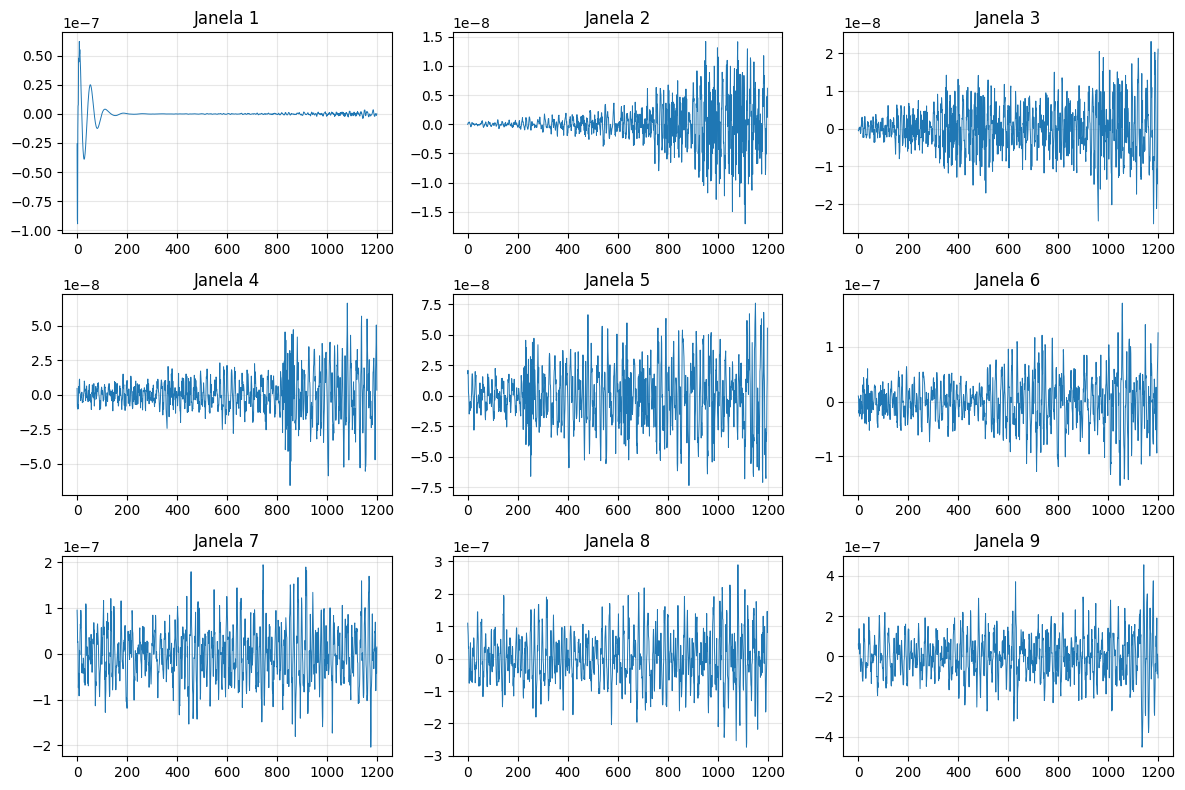

In [12]:
plotar_janelas(janelas_treino[:9])  # primeiras 9 janelas



In [15]:
# Caminhos do evento (ajuste se necessário)
caminho_wave = r"C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\scedc-pds\event_waveforms\2016\2016_001\37509256.ms"
caminho_inv_az = r"C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\scedc-pds\FDSNstationXML\AZ\AZ.BZN.xml"

# Processar o evento
dados_proc, metadados = preprocessar_waveform(
    caminho_wave, caminho_inv_az, 
    canal_alvo='BHZ', output='VEL',
    pre_filt=(0.5, 1.0, 18.0, 20.0),
    normalizar=True, plot=False  # pode colocar True se quiser ver
)

print("Evento processado:")
print("Metadados:", metadados)
print("Shape dados_proc:", dados_proc.shape)

Evento processado:
Metadados: {'network': 'AZ', 'station': 'BZN', 'channel': 'BHZ', 'sampling_rate': 40.0, 'starttime': UTCDateTime(2016, 1, 1, 0, 42, 3, 594500), 'npts': 2640}
Shape dados_proc: (2640,)


In [17]:
import numpy as np
# Usar os dados do evento (dados_proc) e metadados (metadados)
sr_evento = metadados['sampling_rate']  # 40 Hz
janelas_evento = criar_janelas(dados_proc, sr_evento, tamanho_seg, sobreposicao)
print(f"Janelas do evento: {janelas_evento.shape}")

# Rótulos: 1 para evento
y_evento = np.ones(len(janelas_evento))

Janelas do evento: (3, 1200)


In [18]:
import numpy as np

# Supondo que você já tenha janelas_treino (do dado contínuo) e janelas_evento
# Vamos separar os últimos 20% das janelas de ruído para validação
n_total = len(janelas_treino)
n_val_noise = int(0.2 * n_total)

X_train_noise = janelas_treino[:-n_val_noise]
X_val_noise = janelas_treino[-n_val_noise:]

print(f"Janelas de treino (ruído): {X_train_noise.shape}")
print(f"Janelas de validação (ruído): {X_val_noise.shape}")

Janelas de treino (ruído): (32256, 1200)
Janelas de validação (ruído): (8063, 1200)


In [19]:
# Combinar as janelas de validação (ruído) com as janelas de evento
X_val = np.vstack([X_val_noise, janelas_evento])
y_val = np.hstack([np.zeros(len(X_val_noise)), np.ones(len(janelas_evento))])

print("Conjunto de validação final:")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print("Distribuição das classes:", np.bincount(y_val.astype(int)))

Conjunto de validação final:
X_val shape: (8066, 1200)
y_val shape: (8066,)
Distribuição das classes: [8063    3]


In [20]:
import os

# Diretório base para dados processados (ajuste se necessário)
base_dir = r"C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\processed"
continuous_dir = os.path.join(base_dir, "continuous")
events_dir = os.path.join(base_dir, "events")
windows_dir = os.path.join(base_dir, "windows")

# Criar as pastas se não existirem
for d in [continuous_dir, events_dir, windows_dir]:
    os.makedirs(d, exist_ok=True)
    print(f"Pasta garantida: {d}")

Pasta garantida: C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\processed\continuous
Pasta garantida: C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\processed\events
Pasta garantida: C:\Users\vish8\OneDrive\Documentos\SeriesTemporaisSismicas\data\processed\windows


In [21]:
# Salvar dados contínuos processados (array e metadados)
np.save(os.path.join(continuous_dir, "CI.PASC.2016-01-01.npy"), dados_continuos)
np.save(os.path.join(continuous_dir, "CI.PASC.2016-01-01_meta.npy"), meta_continuos)

# Salvar janelas de treino (ruído)
np.save(os.path.join(windows_dir, "janelas_treino_30s_50over.npy"), janelas_treino)

print("Dados contínuos e janelas de treino salvos.")

Dados contínuos e janelas de treino salvos.


In [22]:
# Salvar dados do evento processado (array e metadados)
np.save(os.path.join(events_dir, "AZ.BZN.37509256.npy"), dados_proc)
np.save(os.path.join(events_dir, "AZ.BZN.37509256_meta.npy"), metadados)

# Salvar janelas do evento
np.save(os.path.join(windows_dir, "janelas_evento_30s_50over.npy"), janelas_evento)

print("Dados do evento e janelas salvas.")

Dados do evento e janelas salvas.


In [23]:
# Salvar os conjuntos já separados em um único arquivo .npz
np.savez(os.path.join(windows_dir, "dados_otimizacao.npz"),
         X_train_noise=X_train_noise,
         X_val=X_val,
         y_val=y_val)

print("Conjuntos de treino/validação salvos em 'dados_otimizacao.npz'")

Conjuntos de treino/validação salvos em 'dados_otimizacao.npz'


In [24]:
print("Arquivos em continuous:", os.listdir(continuous_dir))
print("Arquivos em events:", os.listdir(events_dir))
print("Arquivos em windows:", os.listdir(windows_dir))

Arquivos em continuous: ['CI.PASC.2016-01-01.npy', 'CI.PASC.2016-01-01_meta.npy']
Arquivos em events: ['AZ.BZN.37509256.npy', 'AZ.BZN.37509256_meta.npy']
Arquivos em windows: ['dados_otimizacao.npz', 'janelas_evento_30s_50over.npy', 'janelas_treino_30s_50over.npy']


In [25]:
X_train_noise = np.load(os.path.join(windows_dir, "dados_otimizacao.npz"))['X_train_noise']
X_val = np.load(os.path.join(windows_dir, "dados_otimizacao.npz"))['X_val']
y_val = np.load(os.path.join(windows_dir, "dados_otimizacao.npz"))['y_val']